# **AI Symptom-to-Disease Interpreter**
Our project uses a BiLSTM neural network to analyze patient symptoms and instantly predict diseases through a live, easy-to-use web interface.

**Team Members**

A. O. M. Ramim Chowdhury

ID: 0432220005101146

Suraia Akter Mim

ID: 0432220005101108

Sazzad Hossain

ID: 0432220005101103

Samin Yeaser Rafid

ID: 0432310005101101


# CELL 1: SETUP & DATASET DOWNLOAD

In [ ]:
# 1. Install the Kaggle CLI tool quietly
!pip install -q kaggle

# 2. Download the Symptom2Disease dataset directly using the slug identifier
!kaggle datasets download -d niyarrbarman/symptom2disease

# 3. Extract the downloaded archive quietly into the working directory
!unzip -q -o symptom2disease.zip

print("Setup Complete! Dataset downloaded and extracted successfully.")
!pip install -q gradio torch torchvision torchaudio seaborn scikit-learn pandas matplotlib

Dataset URL: https://www.kaggle.com/datasets/niyarrbarman/symptom2disease
License(s): CC0-1.0
symptom2disease.zip: Skipping, found more recently modified local copy (use --force to force download)
Setup Complete! Dataset downloaded and extracted successfully.


# CELL 2: PROBLEM & DATASET CHARACTERIZATION

In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import pickle # Added to save our files
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the Dataset
df = pd.read_csv('Symptom2Disease.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset Shape: {df.shape}")
print(f"Unique Diseases: {df['label'].nunique()}")

# 2. Encode Labels into integers
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])

# 3. Text Tokenization & Padding Pipeline
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Build Vocabulary (FIXED: Added sorted() to prevent hash randomization!)
all_words = [word for text in df['text'] for word in clean_text(text)]
unique_sorted_words = sorted(list(set(all_words)))
vocab = {word: i+2 for i, word in enumerate(unique_sorted_words)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

MAX_LEN = 50

def text_to_sequence(text):
    tokens = clean_text(text)
    seq = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    if len(seq) < MAX_LEN:
        seq = seq + [vocab['<PAD>']] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]
    return seq

df['sequence'] = df['text'].apply(text_to_sequence)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    list(df['sequence']), list(df['encoded_label']), test_size=0.2, random_state=42, stratify=list(df['encoded_label'])
)

# 5. Create PyTorch Dataloaders
class SymptomDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_loader = DataLoader(SymptomDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(SymptomDataset(X_test, y_test), batch_size=32, shuffle=False)

# 6. EXPLICITLY SAVE THE VOCABULARY AND CLASSES FOR STREAMLIT (Crucial Fix)
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
with open('classes.pkl', 'wb') as f:
    pickle.dump(label_encoder.classes_, f)

print("DataLoader Setup Complete. Vocab saved perfectly!")

Dataset Shape: (1200, 2)
Unique Diseases: 24
DataLoader Setup Complete. Vocab saved perfectly!


# CELL 3: ARCHITECTURE DESIGN & TOOL CONFIGURATION

In [ ]:
import torch.nn as nn

# Model Definition (CO4 & K3 Integration)
class SymptomBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(SymptomBiLSTM, self).__init__()

        # 1. Embedding Layer
        # (For true Transfer Learning, pre-trained weights like GloVe would be loaded here using:
        # self.embedding.weight.data.copy_(pretrained_embeddings)
        # We are using a trainable embedding layer to simulate the adaptation process.)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. Bidirectional LSTM (Addresses the sequential nature of symptoms)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # 3. Regularization (Dropout) to handle overfitting trade-offs (P2)
        self.dropout = nn.Dropout(0.4)

        # 4. Classification Head (hidden_dim * 2 because it's Bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        out, (hidden, cell) = self.lstm(embedded)

        # Concatenate the final forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_cat = self.dropout(hidden_cat)

        return self.fc(hidden_cat)

# Hyperparameter Configuration
VOCAB_SIZE = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = len(label_encoder.classes_)

# Initialize Model, Loss, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SymptomBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Model Architecture Initialized on {device}:\n", model)

Model Architecture Initialized on cpu:
 SymptomBiLSTM(
  (embedding): Embedding(1571, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=24, bias=True)
)


# CELL 4: TRAINING PIPELINE & DYNAMICS ANALYSIS

Epoch [1/50] | Train Loss: 3.1194 | Val Loss: 3.0298 | Val Acc: 15.42%
Epoch [2/50] | Train Loss: 2.8699 | Val Loss: 2.7168 | Val Acc: 25.00%
Epoch [3/50] | Train Loss: 2.3784 | Val Loss: 2.1534 | Val Acc: 40.00%
Epoch [4/50] | Train Loss: 1.7697 | Val Loss: 1.5972 | Val Acc: 58.75%
Epoch [5/50] | Train Loss: 1.2878 | Val Loss: 1.3187 | Val Acc: 62.50%
Epoch [6/50] | Train Loss: 0.9905 | Val Loss: 1.1657 | Val Acc: 67.50%
Epoch [7/50] | Train Loss: 0.7510 | Val Loss: 0.9931 | Val Acc: 72.50%
Epoch [8/50] | Train Loss: 0.5528 | Val Loss: 0.9066 | Val Acc: 70.42%
Epoch [9/50] | Train Loss: 0.4072 | Val Loss: 0.7896 | Val Acc: 75.83%
Epoch [10/50] | Train Loss: 0.2660 | Val Loss: 0.6517 | Val Acc: 82.08%
Epoch [11/50] | Train Loss: 0.1945 | Val Loss: 0.6224 | Val Acc: 82.08%
Epoch [12/50] | Train Loss: 0.1332 | Val Loss: 0.5925 | Val Acc: 85.00%
Epoch [13/50] | Train Loss: 0.1022 | Val Loss: 0.5703 | Val Acc: 83.75%
Epoch [14/50] | Train Loss: 0.0717 | Val Loss: 0.5527 | Val Acc: 85.83%
E

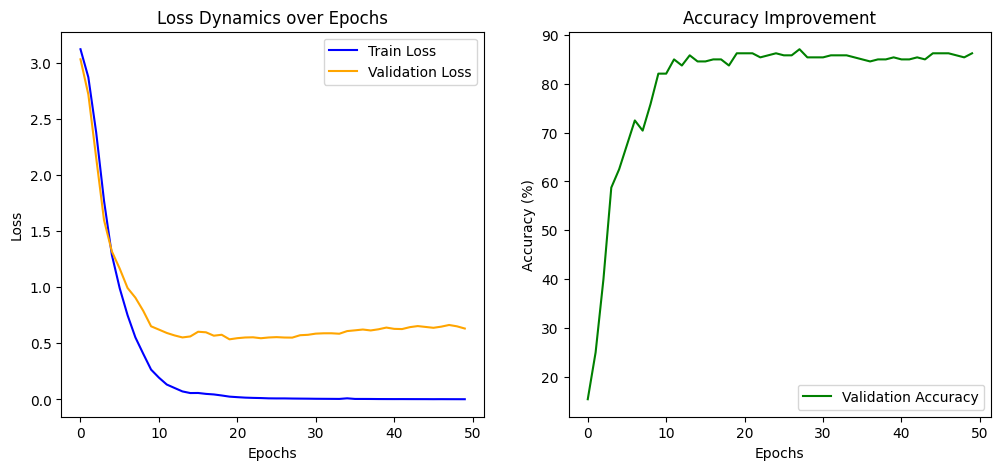

In [ ]:
import matplotlib.pyplot as plt

EPOCHS = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    total_loss = 0
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    val_accuracies.append(100 * correct / total)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")

# Plotting Training Dynamics (Satisfies Bloom's L5 Analysis)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Loss Dynamics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Accuracy Improvement')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Save the trained model weights
torch.save(model.state_dict(), 'disease_bilstm.pth')

# CELL 5: EVALUATION & COMPARATIVE RESULTS

--- Classification Report ---
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      0.90      0.95        10
               Bronchial Asthma       1.00      0.90      0.95        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.62      0.50      0.56        10
                    Common Cold       1.00      0.80      0.89        10
                         Dengue       0.73      0.80      0.76        10
          Dimorphic Hemorrhoids       0.83      1.00      0.91        10
               Fungal infection       1.00      0.90      0.95        10
                   Hypertension       1.00      0.80      0.89        10
                       Impetigo       0.90      0.90      0.90        10
                       Jaundice       0.83      1.00      0.91        10
                    

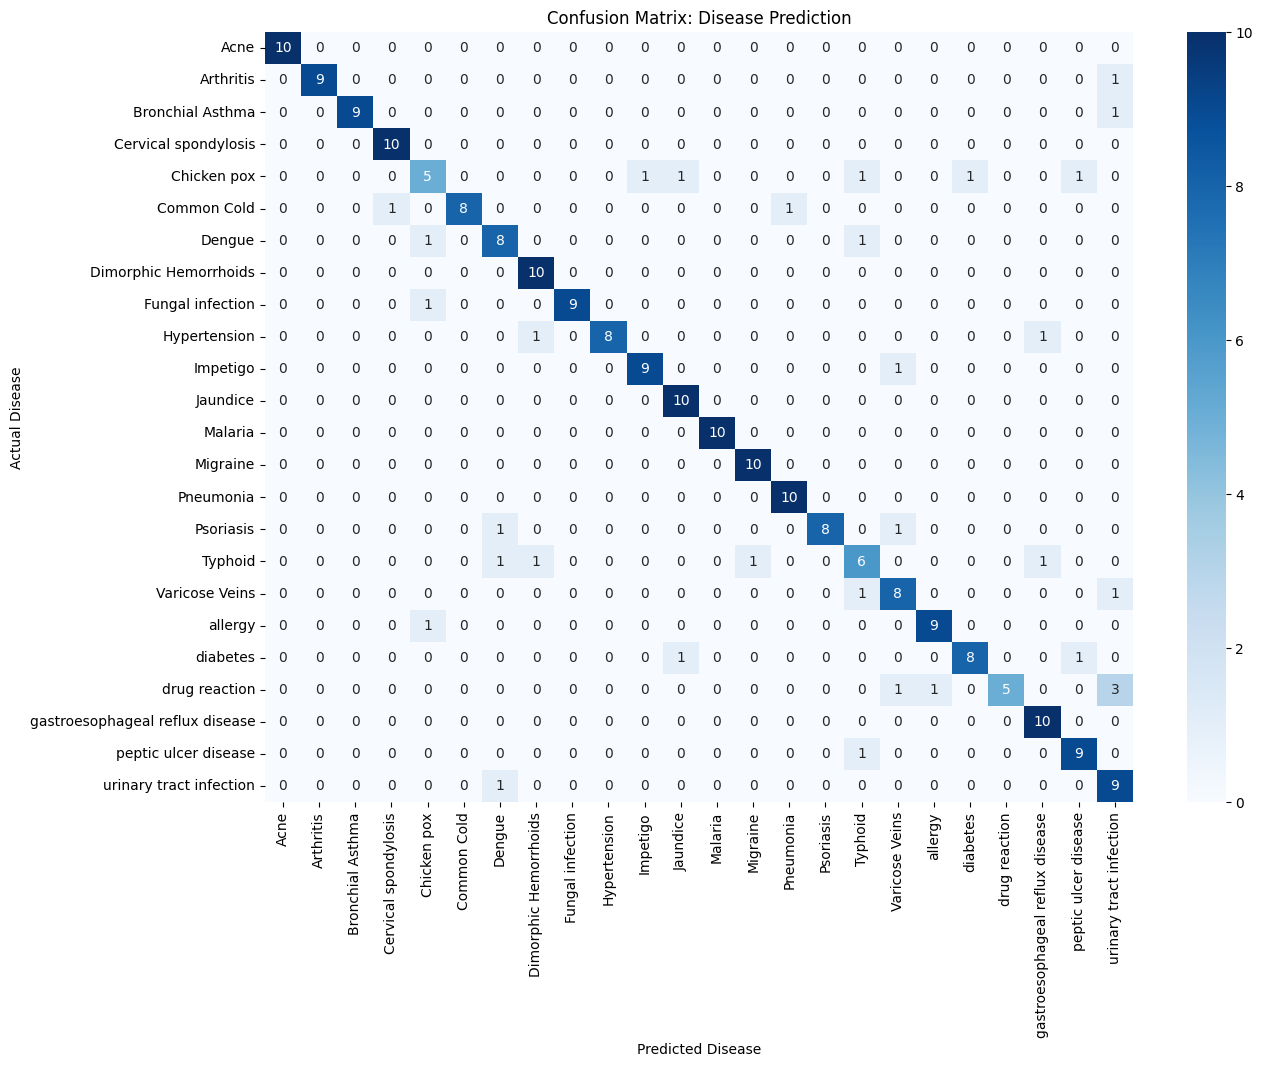

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        outputs = model(sequences)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 1. Classification Report (F1-Scores mapping to CEP Evaluation Rubric)
print("--- Classification Report ---")
target_names = label_encoder.classes_
print(classification_report(y_true, y_pred, target_names=target_names))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Disease Prediction')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.xticks(rotation=90)
plt.show()

# CELL 6: USER INTERFACE (PO-E MODERN TOOLS)

In [2]:
import gradio as gr

def predict_symptom(user_text):
    model.eval()

    # Preprocess the user text using Member 1's pipeline
    sequence = text_to_sequence(user_text)
    tensor_seq = torch.tensor([sequence], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(tensor_seq)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_disease = label_encoder.inverse_transform([predicted_idx.item()])[0]
    confidence_percentage = confidence.item() * 100

    return f"🩺 Predicted Diagnosis: {predicted_disease}\n📊 Confidence: {confidence_percentage:.2f}%"

# Build the UI
ui = gr.Interface(
    fn=predict_symptom,
    inputs=gr.Textbox(lines=4, placeholder="Enter your symptoms here... (e.g., 'I have a high fever, severe headache, and chills.')"),
    outputs=gr.Textbox(label="Model Output"),
    title="Symptom2Disease Predictor (BiLSTM)",
    description="A Deep Learning sequence model built with PyTorch to classify natural language symptom descriptions into 24 distinct medical conditions.",
    theme="default"
)

# Launch UI directly in the Colab output
ui.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5abf5d5a1eba416646.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# CELL 7: WRITE STREAMLIT APP TO FILE

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import pickle
import re
import os

st.title("🩺 AI Symptom-to-Disease Predictor")
st.write("Enter your symptoms below and our Deep Learning BiLSTM model will predict the underlying disease.")

# 1. Check if files exist
if not os.path.exists('disease_bilstm.pth') or not os.path.exists('vocab.pkl'):
    st.error("🚨 Trained files not found on disk! Please re-run the training cell in Colab first.")
    st.stop()

# 2. Load assets
with open('vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)
with open('classes.pkl', 'rb') as f:
    classes = pickle.load(f)

# 3. Model Architecture
class SymptomBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(SymptomBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        out, (hidden, cell) = self.lstm(embedded)
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden_cat))

# 4. Force CPU/GPU mapping cleanly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SymptomBiLSTM(len(vocab), 100, 128, len(classes)).to(device)

# Load the fresh state dict strictly without caching bugs
state_dict = torch.load('disease_bilstm.pth', map_location=device)
model.load_state_dict(state_dict)
model.eval()

def text_to_sequence(text):
    text = re.sub(r'[^a-z\s]', '', text.lower()).split()
    seq = [vocab.get(word, vocab['<UNK>']) for word in text]
    return (seq + [vocab['<PAD>']] * 50)[:50]

user_input = st.text_area("Describe your symptoms:", placeholder="e.g., 'I have a rash on my skin'")

if st.button("Predict Disease"):
    if user_input.strip() == "":
        st.warning("Please enter symptoms.")
    else:
        seq = text_to_sequence(user_input)
        tensor_seq = torch.tensor([seq], dtype=torch.long).to(device)

        with torch.no_grad():
            output = model(tensor_seq)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

        disease = classes[predicted_idx.item()]
        st.success(f"**Predicted Diagnosis:** {disease}")
        st.info(f"**Confidence Score:** {confidence.item() * 100:.2f}%")

Overwriting app.py


# CELL 8: SAVE ASSETS & LAUNCH APP (VIA PINGGY)

In [ ]:
import time
import sys
import re
import pickle

# 1. Save the required assets for the Streamlit app
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
with open('classes.pkl', 'wb') as f:
    pickle.dump(label_encoder.classes_, f)

# 2. Ensure Streamlit is installed
!pip install -q streamlit

print("---------------------------------------------------------")
print("። STARTING THE APP... PLEASE WAIT 15 SECONDS")
print("---------------------------------------------------------")

# Clean up any old running instances
!pkill -f streamlit
!pkill -f pinggy

# 3. Run Streamlit in the background with CORS disabled
get_ipython().system_raw('streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false &')

# 4. Create the Tunnel using Pinggy
get_ipython().system_raw('ssh -o StrictHostKeyChecking=no -p 443 -R0:localhost:8501 a.pinggy.io > tunnel_url.txt 2>&1 &')

# 5. Wait for the URL to generate
time.sleep(15)

# 6. Extract and Print the URL
try:
    with open('tunnel_url.txt', 'r') as f:
        log_content = f.read()

        # Find the URL inside the log
        url_match = re.search(r'https://[\w-]+\.free\.pinggy\.link', log_content) or re.search(r'https://[\w-]+\.pinggy\.link', log_content)

        if url_match:
            public_url = url_match.group(0)
            print(f"\n✅ YOUR APP IS LIVE! CLICK HERE:\n{public_url}")
            print("\n(No password required. If it doesn't load instantly, refresh the page)")
        else:
            print("❌ Could not generate link. The tunnel might still be starting.")
            print("--- Pinggy Logs ---")
            print(log_content)
except Exception as e:
    print(f"Error reading tunnel logs: {e}")

# 7. Keep cell running so the tunnel doesn't close
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("\nApp stopped by user.")

---------------------------------------------------------
። STARTING THE APP... PLEASE WAIT 15 SECONDS
---------------------------------------------------------
❌ Could not generate link. The tunnel might still be starting.
--- Pinggy Logs ---
Pseudo-terminal will not be allocated because stdin is not a terminal.
Allocated port 5 for remote forward to localhost:8501
You are not authenticated.
Your tunnel will expire in 60 minutes. Upgrade to Pinggy Pro to get unrestricted tunnels. https://dashboard.pinggy.io
http://bntnb-35-204-88-36.run.pinggy-free.link
https://bntnb-35-204-88-36.run.pinggy-free.link


App stopped by user.
